# 02 — Value at Risk (VaR) & Conditional Value at Risk (CVaR)
Estimating portfolio downside risk using Historical Simulation and Parametric methods.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)
print(f"Loaded returns: {returns.shape}")
returns.head()

Loaded returns: (1257, 10)


,AAPL,AMZN,BA,BRK-B,GLD,JNJ,JPM,MSFT,PG,XOM
Date,,,,,,,,,,
2020-01-03,-0.009722,-0.012139,-0.001680,-0.009676,0.013269,-0.011578,-0.013196,-0.012452,-0.006726,-0.008040
2020-01-06,0.007968,0.014886,0.002945,0.003581,0.010490,-0.001248,-0.000795,0.002585,0.001387,0.007678
2020-01-07,-0.004703,0.002092,0.010607,-0.004714,0.003935,0.006107,-0.017001,-0.009118,-0.006192,-0.008184
2020-01-08,0.016086,-0.007809,-0.017523,0.000310,-0.007502,-0.000138,0.007801,0.015928,0.004263,-0.015080
2020-01-09,0.021240,0.004799,0.014998,0.011770,-0.005652,0.002967,0.003651,0.012493,0.010938,0.007655


In [3]:
n = len(returns.columns)
weights = np.array([1/n] * n)

# Portfolio daily returns
portfolio_returns = returns.dot(weights)
print(f"Portfolio daily return (mean): {portfolio_returns.mean():.4%}")
print(f"Portfolio daily volatility:    {portfolio_returns.std():.4%}")

Portfolio daily return (mean): 0.0633%
Portfolio daily volatility:    1.2432%


In [4]:
confidence_levels = [0.90, 0.95, 0.99]

print("=== Historical Simulation ===")
for cl in confidence_levels:
    var = np.percentile(portfolio_returns, (1 - cl) * 100)
    cvar = portfolio_returns[portfolio_returns <= var].mean()
    print(f"  {int(cl*100)}% VaR:  {var:.4%}  |  CVaR: {cvar:.4%}")

=== Historical Simulation ===
  90% VaR:  -1.1440%  |  CVaR: -2.1756%
  95% VaR:  -1.6193%  |  CVaR: -2.9679%
  99% VaR:  -3.6035%  |  CVaR: -5.5053%


In [5]:
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()

print("=== Parametric (Variance-Covariance) ===")
for cl in confidence_levels:
    var = norm.ppf(1 - cl, mu, sigma)
    cvar = mu - sigma * norm.pdf(norm.ppf(cl)) / (1 - cl)
    print(f"  {int(cl*100)}% VaR:  {var:.4%}  |  CVaR: {cvar:.4%}")

=== Parametric (Variance-Covariance) ===
  90% VaR:  -1.5300%  |  CVaR: -2.1186%
  95% VaR:  -1.9817%  |  CVaR: -2.5012%
  99% VaR:  -2.8289%  |  CVaR: -3.2502%


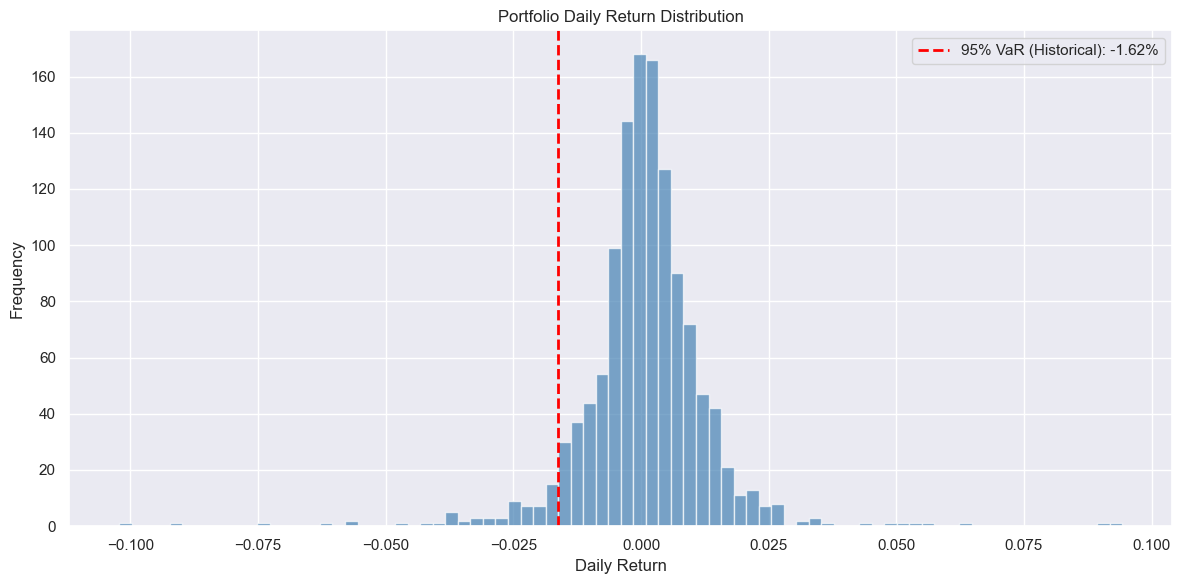

In [6]:
var_95_hist = np.percentile(portfolio_returns, 5)

plt.figure(figsize=(12, 6))
plt.hist(portfolio_returns, bins=80, color="steelblue", edgecolor="white", alpha=0.7)
plt.axvline(var_95_hist, color="red", linestyle="--", linewidth=2, label=f"95% VaR (Historical): {var_95_hist:.2%}")
plt.title("Portfolio Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/var_distribution.png", dpi=150)
plt.show()

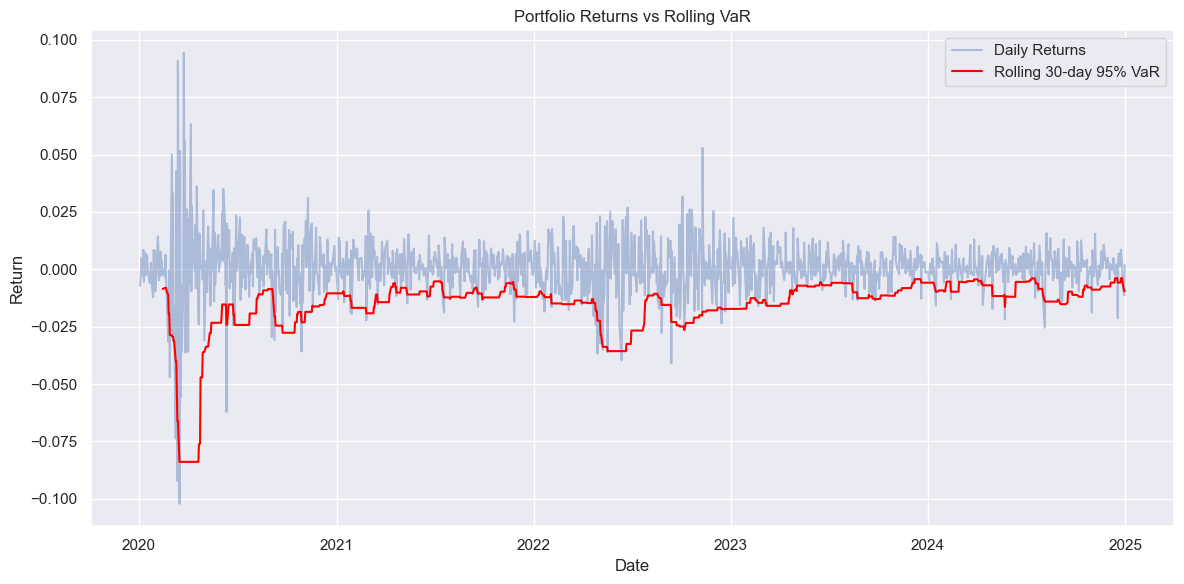

In [7]:
rolling_var = portfolio_returns.rolling(window=30).quantile(0.05)

plt.figure(figsize=(12, 6))
plt.plot(portfolio_returns.index, portfolio_returns, alpha=0.4, label="Daily Returns")
plt.plot(rolling_var.index, rolling_var, color="red", linewidth=1.5, label="Rolling 30-day 95% VaR")
plt.title("Portfolio Returns vs Rolling VaR")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/rolling_var.png", dpi=150)
plt.show()

In [10]:
print("=== Individual Stock VaR & CVaR (95% Historical) ===\n")

individual_stats = []

for ticker in returns.columns:
    stock_returns = returns[ticker]
    var_95 = np.percentile(stock_returns, 5)
    cvar_95 = stock_returns[stock_returns <= var_95].mean()
    individual_stats.append({
        "Ticker": ticker,
        "Mean Daily Return": stock_returns.mean(),
        "Volatility": stock_returns.std(),
        "95% VaR": var_95,
        "95% CVaR": cvar_95
    })

individual_df = pd.DataFrame(individual_stats).set_index("Ticker")
individual_df = individual_df.map(lambda x: f"{x:.4%}")
individual_df

=== Individual Stock VaR & CVaR (95% Historical) ===



,Mean Daily Return,Volatility,95% VaR,95% CVaR
Ticker,,,,
AAPL,0.1182%,1.9956%,-3.0125%,-4.4395%
AMZN,0.0923%,2.2655%,-3.3209%,-5.0468%
BA,0.0020%,3.2178%,-4.3798%,-7.2463%
BRK-B,0.0639%,1.3695%,-1.8935%,-3.0508%
GLD,0.0462%,0.9780%,-1.5887%,-2.2800%
JNJ,0.0179%,1.2382%,-1.7060%,-2.7741%
JPM,0.0746%,2.0490%,-2.8860%,-4.5523%
MSFT,0.0988%,1.9211%,-2.8580%,-4.3063%
PG,0.0429%,1.3181%,-1.7479%,-3.1401%


In [9]:
# Save individual stock risk stats
individual_df.to_csv("../data/individual_var_cvar.csv")

# Save portfolio level summary
portfolio_summary = pd.DataFrame({
    "Metric": ["Mean Daily Return", "Volatility", "90% VaR", "95% VaR", "99% VaR", "90% CVaR", "95% CVaR", "99% CVaR"],
    "Historical": [
        f"{portfolio_returns.mean():.4%}",
        f"{portfolio_returns.std():.4%}",
        f"{np.percentile(portfolio_returns, 10):.4%}",
        f"{np.percentile(portfolio_returns, 5):.4%}",
        f"{np.percentile(portfolio_returns, 1):.4%}",
        f"{portfolio_returns[portfolio_returns <= np.percentile(portfolio_returns, 10)].mean():.4%}",
        f"{portfolio_returns[portfolio_returns <= np.percentile(portfolio_returns, 5)].mean():.4%}",
        f"{portfolio_returns[portfolio_returns <= np.percentile(portfolio_returns, 1)].mean():.4%}"
    ],
    "Parametric": [
        f"{mu:.4%}",
        f"{sigma:.4%}",
        f"{norm.ppf(0.10, mu, sigma):.4%}",
        f"{norm.ppf(0.05, mu, sigma):.4%}",
        f"{norm.ppf(0.01, mu, sigma):.4%}",
        f"{mu - sigma * norm.pdf(norm.ppf(0.90)) / 0.10:.4%}",
        f"{mu - sigma * norm.pdf(norm.ppf(0.95)) / 0.05:.4%}",
        f"{mu - sigma * norm.pdf(norm.ppf(0.99)) / 0.01:.4%}"
    ]
}).set_index("Metric")

portfolio_summary.to_csv("../data/portfolio_var_cvar_summary.csv")

portfolio_summary

,Historical,Parametric
Metric,,
Mean Daily Return,0.0633%,0.0633%
Volatility,1.2432%,1.2432%
90% VaR,-1.1440%,-1.5300%
95% VaR,-1.6193%,-1.9817%
99% VaR,-3.6035%,-2.8289%
90% CVaR,-2.1756%,-2.1186%
95% CVaR,-2.9679%,-2.5012%
99% CVaR,-5.5053%,-3.2502%
